<br/>
<img src="images/utfsm.png" alt="" width="130px" align="left"/>
<img src="images/utfsm.png" alt="" width="130px" align="right"/>
<div align="center">
<h1>Redes Generativas</h1>
<br/><br/>
Dr. Nicolás Gálvez Ramírez<br/>
Dr. Patricio Olivares Roncagliolo<br/><br/>
Ingeniería Civil Telemática<br/>
Departamento de Eléctronica<br/>
Universidad Técnica Federico Santa María
</div>
<br>
Fuentes: 
<br>
"Hands-on Machine Learning with Scikit-Learn, Keras & TensorFlow"

# Auto Encoders (AE)

- Redes Neuronales utilizadas para la reducción de dimensionalidad y la extracción de características.
- Consta de dos partes: un **codificador** (coder) y un **decodificador** (decoder).
- El objetivo de un autoencoder es **minimizar la diferencia entre la entrada ya la reconstrucción**

<img src="images/AE.png" alt="" width="800px" align="center"/>
Fuente: "Hands-on Machine Learning with Scikit-Learn, Keras & TensorFlow"

<img src="images/AE2.png" alt="" width="800px" align="center"/>
Fuente: "https://towardsdatascience.com/applied-deep-learning-part-3-autoencoders-1c083af4d798"

## Aplicaciones de AutoEncoders
- Reducción de dimensionalidad (compresión)
- Eliminación de ruido en imágenes
- Detección de anomalías

<img src="images/AE_noise.png" alt="" width="800px" align="center"/>


In [ ]:
import tensorflow as tf
# Ejemplo usando fashion mnist
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Cost",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"] # 10 clases

X_train_full = X_train_full/255.0 # Escalamiento

from sklearn.model_selection import train_test_split
# Utilización de datos de validación y entrenamiento del modelo
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, 
                                                  stratify=y_train_full)

stacked_encoder = tf.keras.models.Sequential([
tf.keras.layers.Flatten(input_shape=[28, 28]),
tf.keras.layers.Dense(100, activation="selu"),
tf.keras.layers.Dense(30, activation="selu"),
])

stacked_decoder = tf.keras.models.Sequential([
tf.keras.layers.Dense(100, activation="selu", input_shape=[30]),
tf.keras.layers.Dense(28 * 28, activation="sigmoid"),
tf.keras.layers.Reshape([28, 28])
])

stacked_ae = tf.keras.models.Sequential([stacked_encoder, stacked_decoder])

stacked_ae.compile(loss="binary_crossentropy",
optimizer=tf.keras.optimizers.SGD(lr=1.5))
history = stacked_ae.fit(X_train, X_train, epochs=50, validation_data=[X_val, X_val])

2023-11-14 17:27:11.806267: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-14 17:27:16.356639: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-11-14 17:27:17.170355: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/lib/cuda/include:/usr/lib/cuda/lib64:
2023-11-14 17:27:17.170417: W tensorflow/com

Epoch 1/50


2023-11-14 17:27:21.670318: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:630] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-11-14 17:27:21.964306: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x7f2a2a42d4d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-11-14 17:27:21.964323: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2023-11-14 17:27:21.964326: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (1): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2023-11-14 17:27:22.114343: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 [==============================] - 4s 1ms/step - loss: 0.6638 - val_loss: 0.6118
Epoch 2/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.5524 - val_loss: 0.5130
Epoch 3/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.5011 - val_loss: 0.4941
Epoch 4/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.4881 - val_loss: 0.4825
Epoch 5/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.4750 - val_loss: 0.4672
Epoch 6/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.4576 - val_loss: 0.4478
Epoch 7/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.4374 - val_loss: 0.4273
Epoch 8/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.4180 - val_loss: 0.4091
Epoch 9/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.4018 - val_loss: 0.3948
Epoch 10/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3899 - val_los

1500/1500 [==============================] - 1s 483us/step


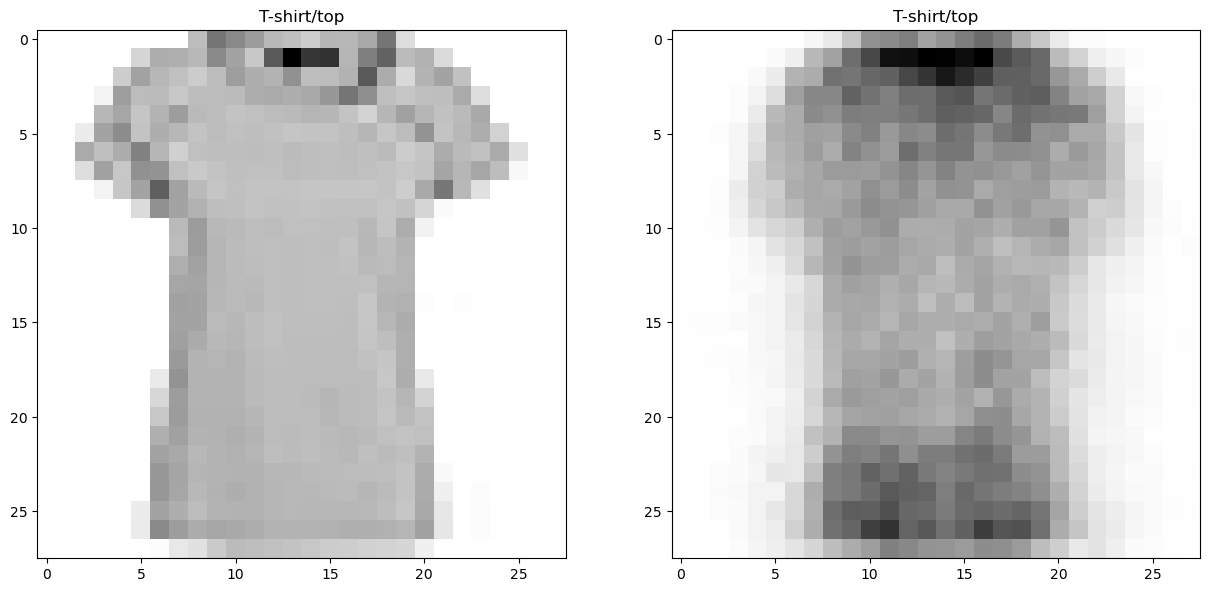

In [3]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15,15))
prediction = stacked_ae.predict(X_train)

i=19

ax1 = fig.add_subplot(1,2,1)
ax1.imshow(X_train[i], cmap='gist_yarg')
ax1.set_title(class_names[y_train[i]])
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(prediction[i], cmap='gist_yarg')
ax2.set_title(class_names[y_train[i]])


plt.show()

# Convolutional Auto Encoder

- Autoencoders diseñados para el procesamiento de imágenes.
- Utilizan capas convolucionales.
- Las capas convolucionales permiten capturar patrones en las imágenes de manera más eficiente.

In [4]:
conv_encoder = tf.keras.models.Sequential([
tf.keras.layers.Reshape([28, 28, 1], input_shape=[28, 28]),
tf.keras.layers.Conv2D(16, kernel_size=3, padding="same", activation="selu"),
tf.keras.layers.MaxPool2D(pool_size=2),
tf.keras.layers.Conv2D(32, kernel_size=3, padding="same", activation="selu"),
tf.keras.layers.MaxPool2D(pool_size=2),
tf.keras.layers.Conv2D(64, kernel_size=3, padding="same", activation="selu"),
tf.keras.layers.MaxPool2D(pool_size=2)
])
conv_decoder = tf.keras.models.Sequential([
tf.keras.layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="valid",activation="selu", input_shape=[3, 3, 64]),
tf.keras.layers.Conv2DTranspose(16, kernel_size=3, strides=2, padding="same",
activation="selu"),
tf.keras.layers.Conv2DTranspose(1, kernel_size=3, strides=2, padding="same",
activation="sigmoid"),
tf.keras.layers.Reshape([28, 28])
])

conv_ae = tf.keras.models.Sequential([conv_encoder, conv_decoder])

conv_ae.compile(loss="binary_crossentropy",
optimizer=tf.keras.optimizers.SGD(lr=1.5))
history = conv_ae.fit(X_train, X_train, epochs=50, validation_data=[X_val, X_val])

Epoch 1/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.5851 - val_loss: 0.4911
Epoch 2/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.4085 - val_loss: 0.3739
Epoch 3/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3654 - val_loss: 0.3550
Epoch 4/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3505 - val_loss: 0.3429
Epoch 5/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3400 - val_loss: 0.3341
Epoch 6/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3324 - val_loss: 0.3274
Epoch 7/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3264 - val_loss: 0.3220
Epoch 8/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3214 - val_loss: 0.3176
Epoch 9/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3173 - val_loss: 0.3139
Epoch 10/50
1500/1500 [==============================] - 5s 3ms/step - loss: 0.313

1500/1500 [==============================] - 2s 2ms/step


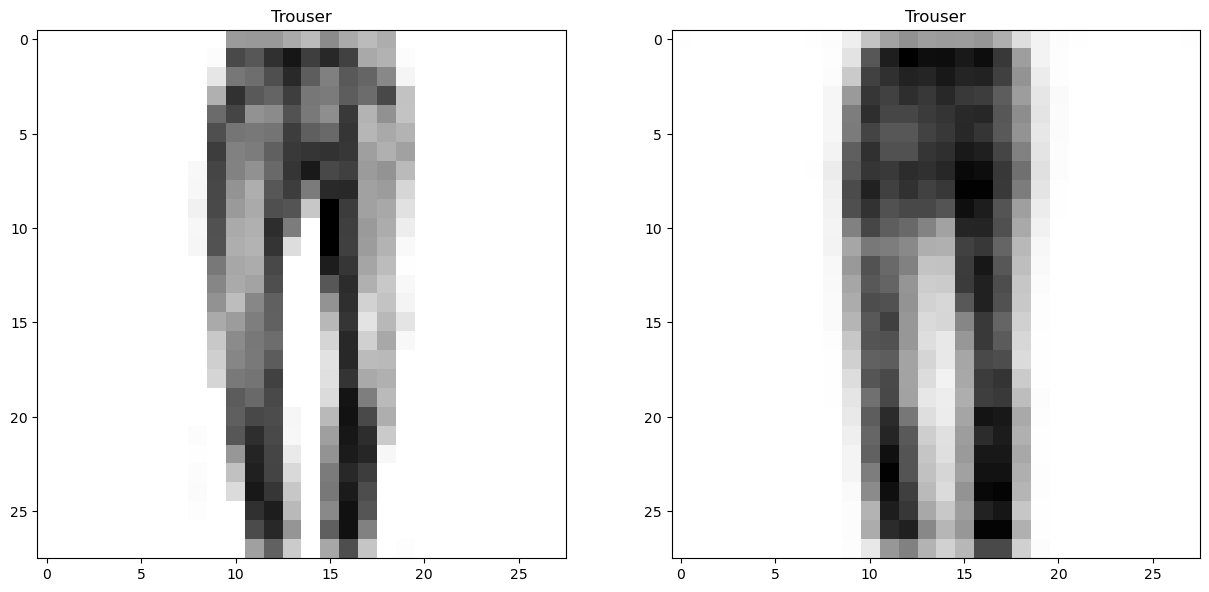

In [6]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15,15))
prediction = conv_ae.predict(X_train)

i=7

ax1 = fig.add_subplot(1,2,1)
ax1.imshow(X_train[i], cmap='gist_yarg')
ax1.set_title(class_names[y_train[i]])
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(prediction[i], cmap='gist_yarg')
ax2.set_title(class_names[y_train[i]])

plt.show()

# Variational Autoencoders (VAE)

- Un Variational Autoencoder (VAE) es una variante de los autoencoders que combina técnicas de reducción de dimensionalidad y generación de datos con modelos generativos probabilísticos
- Un autoencoder tradicional tiene:
    * Un codificador que reduce la dimensionalidad de los datos de entrada a una representación latente
    * Un decodificador que reconstruye los datos originales a partir de la representación latente.
- En un VAE, también tenemos un codificador y un decodificador, pero se introduce un componente probabilístico en el proceso.

<img src="images/VAE_Basic.png" alt="" width="800px" align="center"/>
Fuente: "https://en.wikipedia.org/wiki/Variational_autoencoder"

<img src="images/VAE2.png" alt="" width="800px" align="center"/>
Fuente: "https://towardsdatascience.com/intuitively-understanding-variational-autoencoders-1bfe67eb5daf"

In [7]:
import tensorflow as tf
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        mean, log_var = inputs
        return tf.keras.backend.random_normal(tf.shape(log_var)) * tf.keras.backend.exp(log_var / 2) + mean

codings_size = 10
inputs = tf.keras.layers.Input(shape=[28, 28])
z = tf.keras.layers.Flatten()(inputs)
z = tf.keras.layers.Dense(150, activation="selu")(z)
z = tf.keras.layers.Dense(100, activation="selu")(z)
codings_mean = tf.keras.layers.Dense(codings_size)(z) # μ
codings_log_var = tf.keras.layers.Dense(codings_size)(z) # γ
codings = Sampling()([codings_mean, codings_log_var])
variational_encoder = tf.keras.Model(
inputs=[inputs], outputs=[codings_mean, codings_log_var, codings])

decoder_inputs = tf.keras.layers.Input(shape=[codings_size])
x = tf.keras.layers.Dense(100, activation="selu")(decoder_inputs)
x = tf.keras.layers.Dense(150, activation="selu")(x)
x = tf.keras.layers.Dense(28 * 28, activation="sigmoid")(x)
outputs = tf.keras.layers.Reshape([28, 28])(x)
variational_decoder = tf.keras.Model(inputs=[decoder_inputs], outputs=[outputs])

In [8]:
_, _, codings = variational_encoder(inputs)
reconstructions = variational_decoder(codings)
variational_ae = tf.keras.Model(inputs=[inputs], outputs=[reconstructions])

latent_loss = -0.5 * tf.keras.backend.sum(
1 + codings_log_var - tf.keras.backend.exp(codings_log_var) - tf.keras.backend.square(codings_mean),
axis=-1)
variational_ae.add_loss(tf.keras.backend.mean(latent_loss) / 784.)
variational_ae.compile(loss="binary_crossentropy", optimizer="rmsprop")

In [9]:
history = variational_ae.fit(X_train, X_train, epochs=50, batch_size=128,
validation_data=[X_val, X_val])

Epoch 1/50
375/375 [==============================] - 2s 4ms/step - loss: 0.4208 - val_loss: 0.3696
Epoch 2/50
375/375 [==============================] - 1s 3ms/step - loss: 0.3586 - val_loss: 0.3469
Epoch 3/50
375/375 [==============================] - 1s 3ms/step - loss: 0.3467 - val_loss: 0.3470
Epoch 4/50
375/375 [==============================] - 1s 3ms/step - loss: 0.3398 - val_loss: 0.3388
Epoch 5/50
375/375 [==============================] - 1s 3ms/step - loss: 0.3354 - val_loss: 0.3296
Epoch 6/50
375/375 [==============================] - 1s 3ms/step - loss: 0.3320 - val_loss: 0.3314
Epoch 7/50
375/375 [==============================] - 1s 3ms/step - loss: 0.3295 - val_loss: 0.3270
Epoch 8/50
375/375 [==============================] - 1s 3ms/step - loss: 0.3277 - val_loss: 0.3235
Epoch 9/50
375/375 [==============================] - 1s 3ms/step - loss: 0.3262 - val_loss: 0.3240
Epoch 10/50
375/375 [==============================] - 1s 3ms/step - loss: 0.3248 - val_loss: 0.3217

1500/1500 [==============================] - 2s 1ms/step


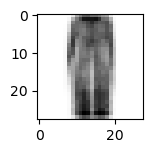

In [13]:
codings = tf.random.normal(shape=[12, codings_size])
images = variational_decoder(codings).numpy()

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(3,3))
prediction = conv_ae.predict(X_train)

i=8

ax1 = fig.add_subplot(1,2,1)
ax1.imshow(images[i], cmap='gist_yarg')
plt.show()

En los VAE, el codificador crea instancias a partir del muestreo de las variables latentes, lo que habilita a estos modelos para generar datos distintos de los que se utilizaron en su entrenamiento inicial.

# Generative Adversarial Networks (GAN)

Las Redes Generativas Adversarias (GAN por sus siglas en inglés), es una arquitectura de red neuronal que se utiliza para generar datos.
Consta de dos componentes:
- El Generador: El cual crea nuevos datos a partir de un ruido aleatorio o un vector de entrada
- El Discriminador: Este evalúa si un dato es real (proveniente de un conjunto de entrenamiento real) o falso (generado por el generador)

<img src="images/GAN.png" alt="" width="800px" align="center"/>
Fuente: "https://www.microsoft.com/en-us/research/blog/how-can-generative-adversarial-networks-learn-real-life-distributions-easily/"

## Entrenamiento de una red GAN

El entrenamiento consta de dos etapas:
- **Entrenamiento del discriminador**: En la primera fase, alimentamos al generador con ruido gaussiano para producir imágenes falsas. Completamos este lote concatenando un número igual de imágenes reales. Las etiquetas se establecen en 0 para imágenes falsas y 1 para imágenes reales. Luego, entrenamos al discriminador en este lote.
- **Entrenamiento del generador**: En la segunda fase, suministramos ruido gaussiano al modelo GAN. El generador producirá inicialmente imágenes falsas y el discriminador intentará determinar si estas imágenes son falsas o reales. Queremos que el discriminador crea que las imágenes falsas son reales, por lo que las etiquetas se establecen en 1.



## Entrenamiento de una GAN

El entrenamiento de una GAN consiste en un **juego adversarial** entre dos redes:

### **1. Entrenamiento del Discriminador**

* Se mezclan **imágenes reales** (etiqueta 1) con **imágenes falsas** generadas por el generador (etiqueta 0).
* El discriminador aprende a distinguir entre ambas, ajustando sus parámetros para maximizar:
  $$
  \log D(x) + \log (1 - D(G(z)))
  $$
    * **$\log D(x)$**: mide qué tan bien clasifica como *real* a una imagen real.
    * **$\log (1 - D(G(z))))$**: mide qué tan bien clasifica como *falsa* a una imagen generada.
    * El discriminador mejora cuando maximiza ambas partes.


### **2. Entrenamiento del Generador**

* Se alimenta el generador con ruido para producir imágenes falsas.
* Estas imágenes pasan por el discriminador, pero ahora **las etiquetas se ponen en 1**, porque queremos que el generador “engañe” al discriminador.
* El generador aprende a aumentar la probabilidad de que el discriminador clasifique sus imágenes como reales:
  $$
  \log D(G(z))
  $$
    * **$D(G(z))$** es la probabilidad que el discriminador asigna a que una imagen falsa sea real.
    * El generador mejora cuando **esta probabilidad aumenta**, es decir, cuando produce imágenes más convincentes.


## Dinámica general

* Ambos modelos se entrenan alternadamente en cada iteración.
* El objetivo final es que el generador produzca datos tan realistas que el discriminador **no pueda distinguirlos mejor que al azar (50%)**.
* El entrenamiento es inestable: si uno de los modelos se vuelve demasiado fuerte, el otro deja de aprender.



## Ejemplo de generación simple: del ruido a la imagen

Este ejemplo muestra cómo un generador simple puede transformar ruido aleatorio en imágenes estilo MNIST, sin necesidad de un discriminador ni entrenamiento adversarial.

- Se utiliza un modelo en Keras que combina capas densas y `Conv2DTranspose` para generar imágenes de forma `(28, 28, 1)`.
- Los pesos son aleatorios y no se optimizan: el objetivo es observar cómo una red puede producir patrones visuales a partir de ruido.
- Sirve como antesala a las GANs, ilustrando el rol del generador y la necesidad posterior de entrenamiento guiado.
- Introduce el concepto de espacio latente (`z`) como entrada clave en modelos generativos.

2025-11-21 11:41:42.017859: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-21 11:41:42.241781: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763736102.318060  148566 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763736102.340656  148566 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763736102.446831  148566 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

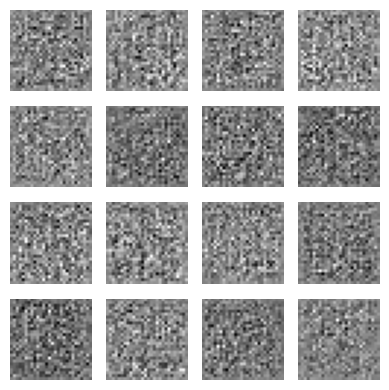

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Dimensión del vector de ruido (espacio latente)
z_dim = 100

# Modelo generador
def build_generator():
    model = tf.keras.Sequential()
    model.add(layers.Dense(7 * 7 * 128, input_shape=(z_dim,)))
    model.add(layers.Reshape((7, 7, 128)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Capa final que genera una imagen de 28x28 con 1 canal (escala de grises),
    # aplicando sigmoid a cada pixel para obtener valores entre 0 y 1
    model.add(layers.Conv2DTranspose(1, kernel_size=4, strides=2, padding='same', activation='sigmoid'))
    return model

# Crear el generador
generator = build_generator()

# Generar un batch de vectores de ruido
num_images = 16
noise = tf.random.normal([num_images, z_dim])

# Generar imágenes
generated_images = generator(noise, training=False)

# Visualizar las imágenes generadas
plt.figure(figsize=(4, 4))
for i in range(num_images):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i, :, :, 0], cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Entrenando una GAN completa con imágenes MNIST

En este ejemplo combinamos un generador y un discriminador para construir una GAN funcional. El generador transforma ruido en imágenes estilo MNIST, mientras que el discriminador intenta distinguir entre imágenes reales y generadas.

- El generador es el mismo modelo usado previamente: transforma un vector de ruido en una imagen `28x28x1` mediante `Dense` y `Conv2DTranspose`.
- El discriminador es una red convolucional que clasifica imágenes como reales o falsas.
- Ambos modelos se entrenan de manera alternada: el discriminador aprende a distinguir, y el generador aprende a engañar.
- Al finalizar cada época, se visualizan ejemplos generados para observar el progreso.

Este ejercicio muestra el principio del entrenamiento adversarial, núcleo de las GANs.

/home/polivares/.local/share/mamba/envs/DataScience/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1763736169.447602  148566 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_2_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-11-21 11:42:55.995112: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Época 0 completada


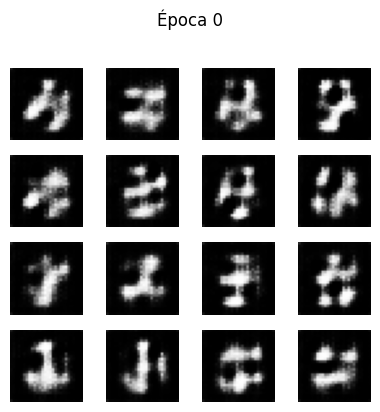

2025-11-21 11:43:00.501813: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Época 1 completada
Época 2 completada


2025-11-21 11:43:08.849699: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Época 3 completada
Época 4 completada
Época 5 completada
Época 6 completada


2025-11-21 11:43:25.856747: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Época 7 completada
Época 8 completada
Época 9 completada
Época 10 completada


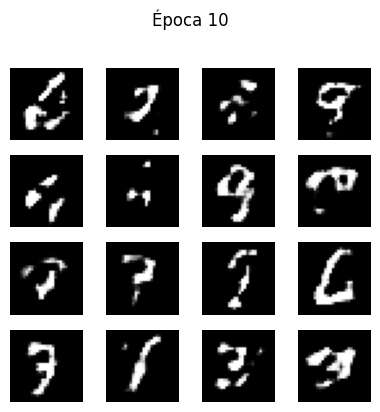

Época 11 completada
Época 12 completada
Época 13 completada
Época 14 completada


2025-11-21 11:44:03.454637: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Época 15 completada
Época 16 completada
Época 17 completada
Época 18 completada
Época 19 completada
Época 20 completada


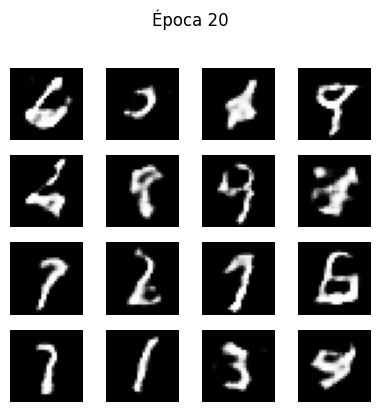

Época 21 completada
Época 22 completada
Época 23 completada
Época 24 completada
Época 25 completada
Época 26 completada
Época 27 completada
Época 28 completada
Época 29 completada
Época 30 completada


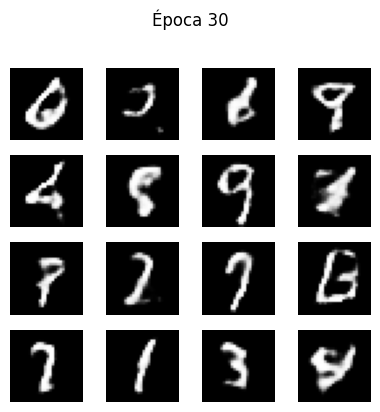

2025-11-21 11:45:24.729039: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Época 31 completada
Época 32 completada
Época 33 completada
Época 34 completada
Época 35 completada
Época 36 completada
Época 37 completada
Época 38 completada
Época 39 completada
Época 40 completada


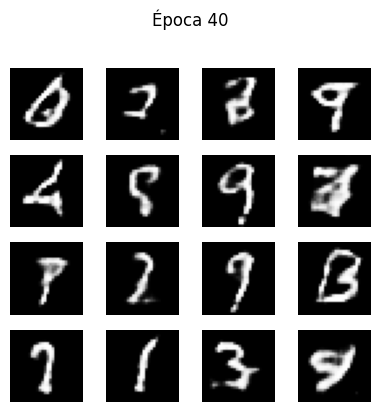

Época 41 completada
Época 42 completada
Época 43 completada
Época 44 completada
Época 45 completada
Época 46 completada
Época 47 completada
Época 48 completada
Época 49 completada
Época 50 completada


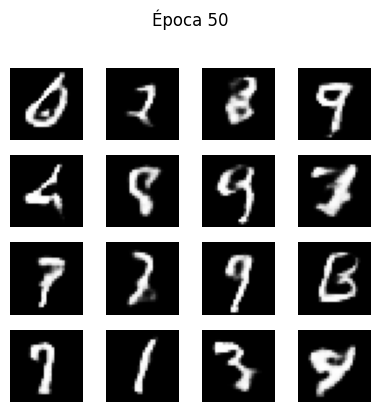

Época 51 completada
Época 52 completada
Época 53 completada
Época 54 completada
Época 55 completada
Época 56 completada
Época 57 completada
Época 58 completada
Época 59 completada
Época 60 completada


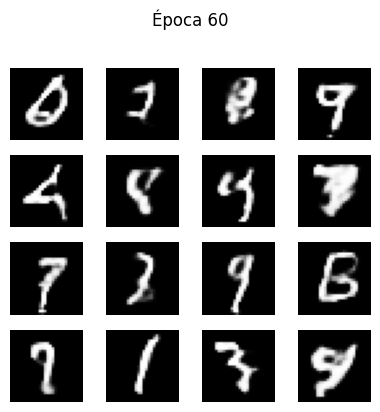

Época 61 completada
Época 62 completada


2025-11-21 11:48:26.570471: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Época 63 completada
Época 64 completada
Época 65 completada
Época 66 completada
Época 67 completada
Época 68 completada
Época 69 completada
Época 70 completada


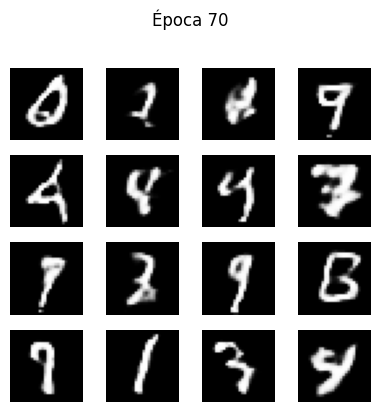

Época 71 completada
Época 72 completada
Época 73 completada
Época 74 completada
Época 75 completada
Época 76 completada
Época 77 completada
Época 78 completada
Época 79 completada
Época 80 completada


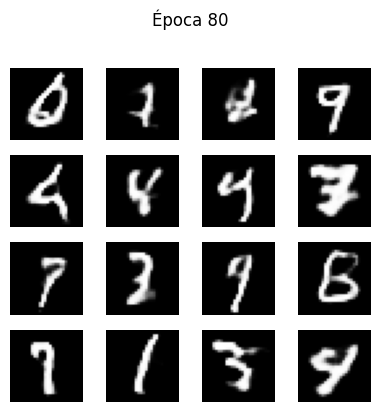

Época 81 completada
Época 82 completada
Época 83 completada
Época 84 completada
Época 85 completada
Época 86 completada
Época 87 completada
Época 88 completada
Época 89 completada
Época 90 completada


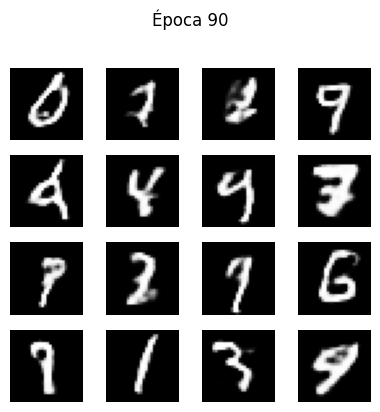

Época 91 completada
Época 92 completada
Época 93 completada
Época 94 completada
Época 95 completada
Época 96 completada
Época 97 completada
Época 98 completada
Época 99 completada
Época 100 completada


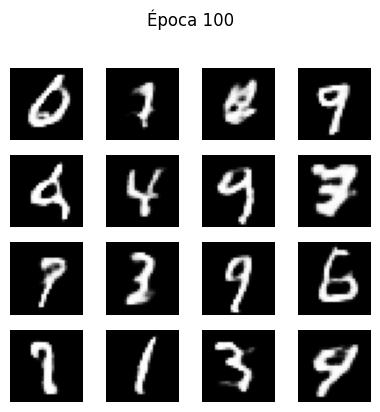

In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Parámetros 
z_dim = 100               # Dimensión del vector de ruido de entrada
BUFFER_SIZE = 60000       # Cantidad total de imágenes en MNIST
BATCH_SIZE = 128          # Tamaño del batch
EPOCHS = 101              # Número total de épocas de entrenamiento

# Generador 
def build_generator():
    model = tf.keras.Sequential()
    # Proyecta el vector de ruido a un volumen 7x7x128
    model.add(layers.Dense(7 * 7 * 128, input_shape=(z_dim,)))
    model.add(layers.Reshape((7, 7, 128)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsampling: 7x7x128 -> 14x14x64
    model.add(layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsampling final: 14x14x64 -> 28x28x1
    # Usa sigmoid para generar valores entre 0 y 1 (escala de grises)
    model.add(layers.Conv2DTranspose(1, kernel_size=4, strides=2, padding='same', activation='sigmoid'))
    return model

generator = build_generator()

# Discriminador
def build_discriminator():
    model = tf.keras.Sequential()
    # Conv2D: reduce tamaño espacial y extrae patrones
    model.add(layers.Conv2D(64, (5, 5), strides=2, padding='same', input_shape=(28, 28, 1)))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Segunda capa convolucional
    model.add(layers.Conv2D(128, (5, 5), strides=2, padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Aplanamiento y salida binaria (probabilidad real/falsa)
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

discriminator = build_discriminator()

# Pérdidas y optimizadores
cross_entropy = tf.keras.losses.BinaryCrossentropy()

# Función de pérdida del discriminador (real vs falsa)
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)   # reales deben clasificarse como 1
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)  # falsas deben clasificarse como 0
    return real_loss + fake_loss

# Función de pérdida del generador (quiere engañar al discriminador)
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)  # idealmente, el D(iscriminador) dice que lo falso es real

# Optimizadores independientes
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# Dataset MNIST
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()
# Normalizar a [0, 1] y añadir canal de profundidad
train_images = (train_images.astype('float32') / 255.0).reshape(-1, 28, 28, 1)
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# Entrenamiento por pasos
# Esta función representa un solo paso de entrenamiento de la GAN.
# Se entrena el generador y el discriminador usando un batch del dataset.
@tf.function  # Optimiza la función compilándola como un grafo computacional (mejora rendimiento)
def train_step(images, generator, discriminator):
    # 1. Se genera un batch de vectores de ruido (uno por imagen real del batch)
    noise = tf.random.normal([BATCH_SIZE, z_dim])

    # 2. Se definen dos "cintas" de gradientes para grabar las operaciones de cada red por separado
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 3. El generador produce imágenes falsas a partir del ruido
        generated_images = generator(noise, training=True)

        # 4. El discriminador evalúa tanto imágenes reales como generadas
        real_output = discriminator(images, training=True)              # Salida para imágenes reales
        fake_output = discriminator(generated_images, training=True)    # Salida para imágenes falsas

        # 5. Se calcula la pérdida del generador (quiere que el D diga que sus imágenes son reales)
        gen_loss = generator_loss(fake_output)

        # 6. Se calcula la pérdida del discriminador (quiere distinguir reales vs falsas correctamente)
        disc_loss = discriminator_loss(real_output, fake_output)

    # 7. Se obtienen los gradientes del generador respecto a su pérdida
    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    # 8. Se aplica el optimizador para actualizar los pesos del generador
    generator_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))

    # 9. Se obtienen los gradientes del discriminador respecto a su pérdida
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    # 10. Se aplica el optimizador para actualizar los pesos del discriminador
    discriminator_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

    # Se retorna la pérdida de ambas redes (opcional, útil para monitoreo)
    return gen_loss, disc_loss

#  Entrenamiento completo
def train(generator, discriminator, dataset, epochs):
    seed = tf.random.normal([16, z_dim])  # Semilla para imágenes consistentes en cada visualización
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch, generator, discriminator)
        print(f"Época {epoch} completada")
        if epoch % 10 == 0:
            generate_and_plot_images(generator, epoch, seed)

# Visualización de imágenes generadas
def generate_and_plot_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Época {epoch}", y=1.02)
    plt.tight_layout()
    plt.show()

# Ejecutar entrenamiento
train(generator, discriminator, train_dataset, EPOCHS)

In [12]:
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")
#codigo extra, para que imagenes de matplotlib
#estén centradas en las diapositivas, ejecutar antes de lanzar los ejemplos.